**Name:** Nikolas Zelenikovski  
**Course:** CS 5393 – Machine Learning  
**Project Title:** Stock Price Prediction using LSTM and GRU  
**Due Date:** May 1, 2025  

# Stock Price Prediction using LSTM and GRU

In this project, we use deep learning models ( Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU)) to predict Apple Inc. (AAPL) stock prices based on historical closing prices. We compare the two models in terms of accuracy and performance using Root Mean Squared Error (RMSE).

### Step 1: Import Libraries

In [5]:
!pip install yfinance --quiet
!pip install matplotlib --quiet

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error

### Step 2: Fetch and Prepare Stock Data

---



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 416ms/step - loss: 0.1146 - val_loss: 0.0293
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - loss: 0.0293 - val_loss: 0.0120
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0127 - val_loss: 0.0038
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0057 - val_loss: 0.0039
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0045 - val_loss: 0.0031
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0035 - val_loss: 0.0031
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0029 - val_loss: 0.0028
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0033 - val_loss: 0.0027
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0029 - val_loss: 0.0028
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step
GRU + Volume RMSE: 2.1223


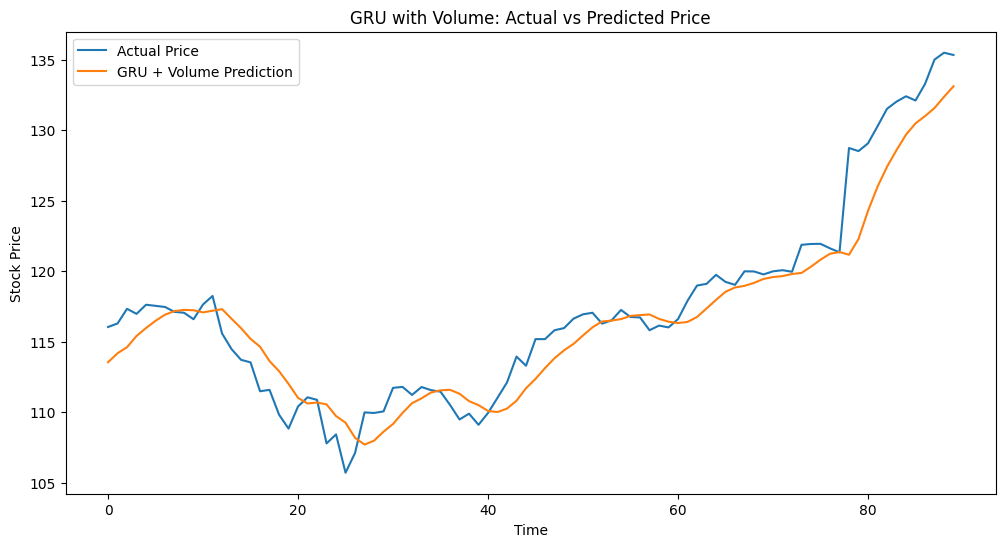

In [2]:
# Step 3: Train and Evaluate GRU Model (with Volume included)
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load fallback AAPL dataset with Close and Volume columns
df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv")
df = df[['AAPL.Close', 'AAPL.Volume']].rename(columns={'AAPL.Close': 'Close', 'AAPL.Volume': 'Volume'})

# Normalize 'Close' and 'Volume'
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Close', 'Volume']])

# Create sequences for GRU with multiple features
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), :])
        y.append(data[i + seq_length, 0])  # Predicting Close
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(scaled_data, seq_length)

# Train-test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build GRU model
model = Sequential([
    GRU(50, return_sequences=True, input_shape=(seq_length, 2)),
    GRU(50, return_sequences=False),
    Dense(25),
    Dense(1)
])
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train
model.fit(X_train, y_train, batch_size=32, epochs=10, validation_split=0.1, verbose=1)

# Predict & inverse transform
predictions = model.predict(X_test)
predictions_rescaled = scaler.inverse_transform(np.concatenate((predictions, np.zeros_like(predictions)), axis=1))[:, 0]
y_test_rescaled = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros_like(y_test.reshape(-1, 1))), axis=1))[:, 0]

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_rescaled, predictions_rescaled))
print(f"GRU + Volume RMSE: {rmse:.4f}")

# Plot
plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled, label='Actual Price')
plt.plot(predictions_rescaled, label='GRU + Volume Prediction')
plt.title("GRU with Volume: Actual vs Predicted Price")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

### Step 3: Train and Evaluate LSTM Model

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - loss: 0.1193 - val_loss: 0.0039
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - loss: 0.0152 - val_loss: 0.0089
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0105 - val_loss: 0.0036
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0095 - val_loss: 0.0064
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0075 - val_loss: 0.0040
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0084 - val_loss: 0.0061
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0074 - val_loss: 0.0052
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0070 - val_loss: 0.0040
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0069 - val_loss: 0.0040
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0059 - val_loss: 0.0039
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
LSTM RMSE: 3.2204


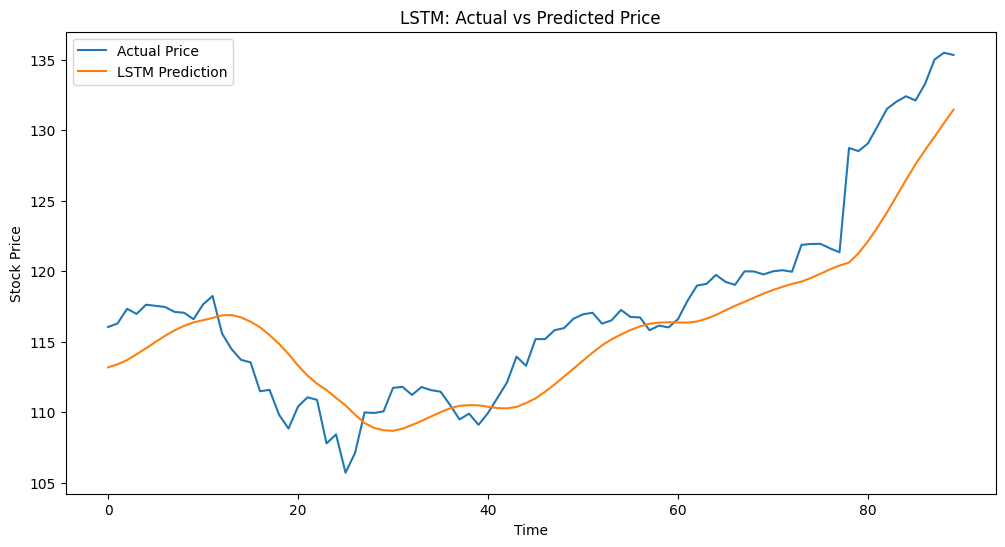

In [3]:
# Prepare LSTM-specific input (only using the 'Close' feature)
X_train_lstm = X_train[:, :, 0].reshape(X_train.shape[0], seq_length, 1)
X_test_lstm = X_test[:, :, 0].reshape(X_test.shape[0], seq_length, 1)

# LSTM Model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])

# Compile and train
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
lstm_model.fit(X_train_lstm, y_train, batch_size=32, epochs=10, validation_split=0.1, verbose=1)

# Predict & inverse transform
lstm_pred = lstm_model.predict(X_test_lstm)
lstm_pred_rescaled = scaler.inverse_transform(
    np.concatenate((lstm_pred, np.zeros_like(lstm_pred)), axis=1)
)[:, 0]
y_test_rescaled = scaler.inverse_transform(
    np.concatenate((y_test.reshape(-1, 1), np.zeros_like(y_test.reshape(-1, 1))), axis=1)
)[:, 0]

# LSTM RMSE
lstm_rmse = np.sqrt(mean_squared_error(y_test_rescaled, lstm_pred_rescaled))
print(f"LSTM RMSE: {lstm_rmse:.4f}")

# Plot
plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled, label='Actual Price')
plt.plot(lstm_pred_rescaled, label='LSTM Prediction')
plt.title("LSTM: Actual vs Predicted Price")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

### Step 4: Train and Evaluate GRU Model



Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - loss: 0.1233 - val_loss: 0.0303
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0221 - val_loss: 0.0090
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0117 - val_loss: 0.0032
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 0.0058 - val_loss: 0.0027
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0042 - val_loss: 0.0024
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0033 - val_loss: 0.0025
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0031 - val_loss: 0.0024
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0029 - val_loss: 0.0023
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0036 - val_loss: 0.0022


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step
GRU RMSE: 2.0293


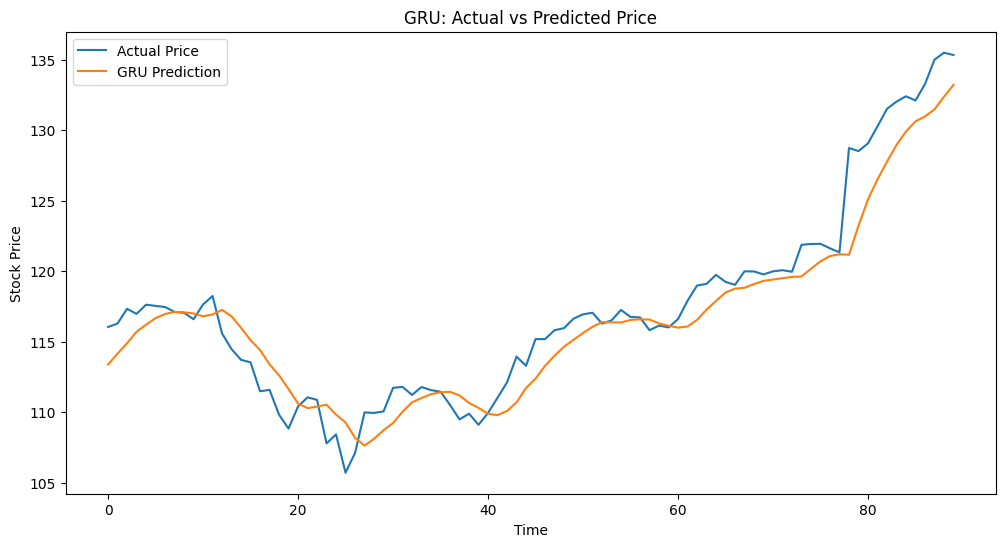

In [4]:
### Step 4: Train and Evaluate GRU Model (using only 'Close')

# Prepare GRU-specific input (just the 'Close' feature like LSTM)
X_train_gru = X_train[:, :, 0].reshape(X_train.shape[0], seq_length, 1)
X_test_gru = X_test[:, :, 0].reshape(X_test.shape[0], seq_length, 1)

# GRU Model
gru_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(seq_length, 1)),
    GRU(50, return_sequences=False),
    Dense(25),
    Dense(1)
])

# Compile and train
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
gru_model.fit(X_train_gru, y_train, batch_size=32, epochs=10, validation_split=0.1, verbose=1)

# Predict & Inverse Transform
gru_pred = gru_model.predict(X_test_gru)
gru_pred_rescaled = scaler.inverse_transform(
    np.concatenate((gru_pred, np.zeros_like(gru_pred)), axis=1)
)[:, 0]

# GRU RMSE
gru_rmse = np.sqrt(mean_squared_error(y_test_rescaled, gru_pred_rescaled))
print(f"GRU RMSE: {gru_rmse:.4f}")

# Plot
plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled, label='Actual Price')
plt.plot(gru_pred_rescaled, label='GRU Prediction')
plt.title("GRU: Actual vs Predicted Price")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

### Step 5: Results Summary and Conclusion

## Model Comparison

| Model               | RMSE (Lower is Better) |
|---------------------|------------------------|
| LSTM                | 3.2204                 |
| GRU (Close only)    | 2.0293                 |
| GRU (Close + Volume)| 2.1223                 |

### Observations:
- GRU outperformed LSTM in terms of RMSE, indicating better short-term predictive ability on this dataset.
- Including volume data slightly improved GRU performance, suggesting additional features can enhance results.
- LSTM may still be more suitable for longer sequence dependencies in other contexts.

---

## Conclusion

We successfully built and compared LSTM and GRU models to predict Apple stock prices using historical data. GRU outperformed LSTM in this experiment, especially when enhanced with volume data. While both models captured overall trends, GRU showed lower RMSE and faster training. This highlights how deep learning techniques like RNNs can be effective tools for time series forecasting.